In [ ]:
# Update files
import importlib
import utils.io
import data.data_loader
import config as cfg
importlib.reload(utils.io)
importlib.reload(data.data_loader)
importlib.reload(cfg)

# Import libraries
import pandas as pd
import torch
import torchvision.transforms as transforms
import torch.optim as optim
import torch.utils.data as data
import torch.nn as nn

# Choose device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():    
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

ERROR: Error in parse(text = input): <text>:2:8: unexpected symbol
1: # Update files
2: import importlib
          ^


## First, we read the dataset, preprocess the images and encapsulate them into dataloader form.

In [ ]:
from data.data_loader import ButterflyDataset
from utils.io import print_images
from utils.metrics import analyze_df
from sklearn.model_selection import train_test_split

# load the data
df = pd.read_csv(cfg.TRAIN_LABELS_PATH)

df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

# preprocessing
data_transform = transforms.Compose([
    transforms.Resize((cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)),
    transforms.ToTensor()
])

train_dataset = ButterflyDataset(df=df_train, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)
val_dataset = ButterflyDataset(df=df_val, img_dir=cfg.TRAIN_IMG_DIR, transform=data_transform)

train_loader = data.DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True)
val_loader = data.DataLoader(val_dataset, batch_size=cfg.BATCH_SIZE, shuffle=False)
print("All images proccessed...")


ERROR: Error in parse(text = input): <text>:1:6: unexpected symbol
1: from data.data_loader
         ^


#### TRAIN DATASET ####
                          Quantidade de Imagens  Proporção (%)
label                                                         
MOURNING CLOAK                               84       2.019716
SLEEPY ORANGE                                68       1.635008
ATALA                                        64       1.538831
BROWN SIPROETA                               63       1.514787
BANDED ORANGE HELICONIAN                     62       1.490743
...                                         ...            ...
AMERICAN SNOOT                               47       1.130079
GOLD BANDED                                  46       1.106035
WOOD SATYR                                   46       1.106035
CRIMSON PATCH                                46       1.106035
MALACHITE                                    46       1.106035

[75 rows x 2 columns]


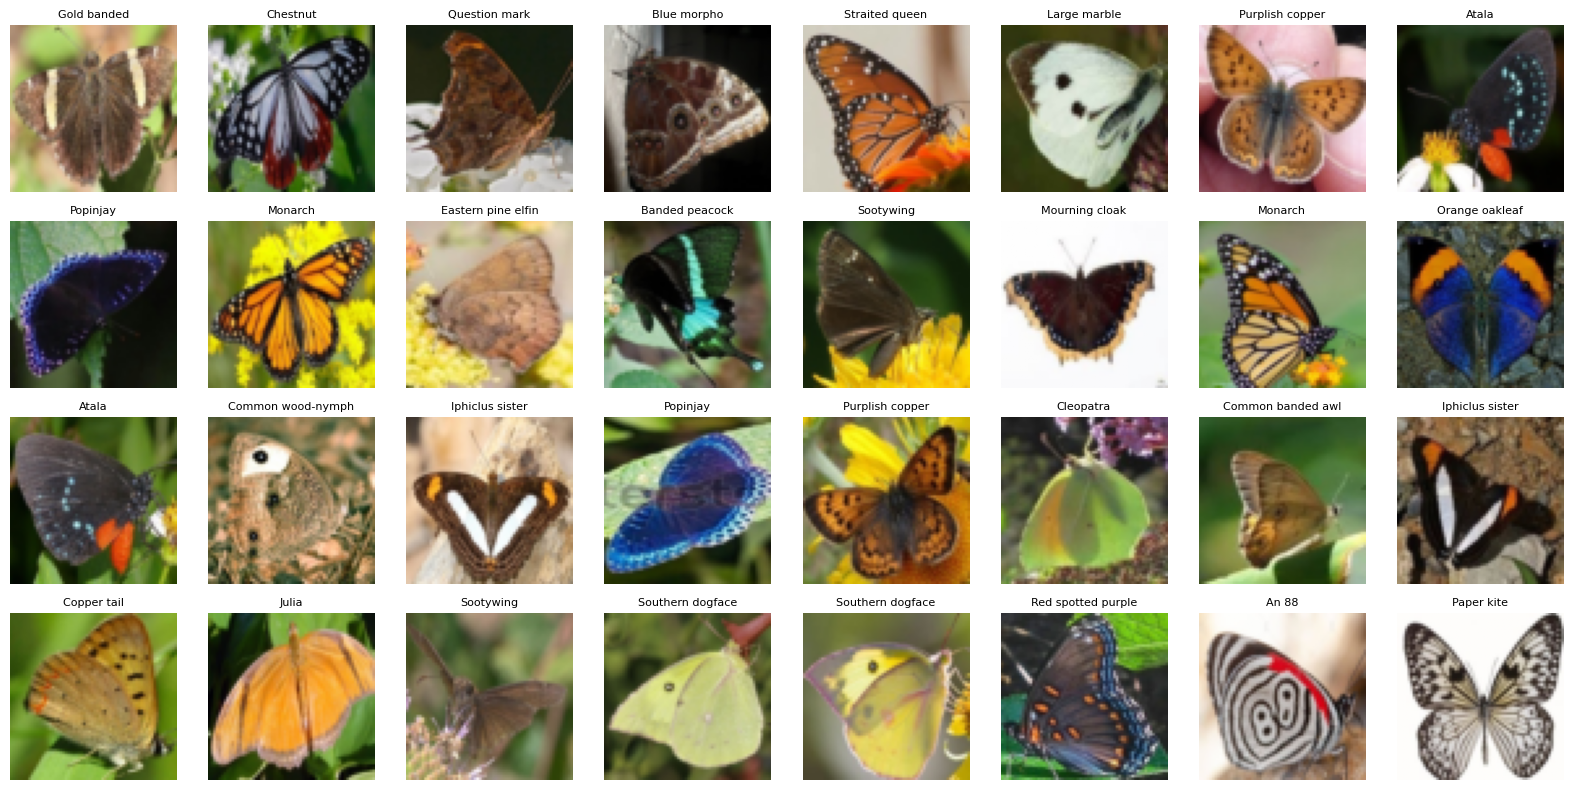

In [ ]:
# Train data set analyze
print("#### TRAIN DATASET ####")
analyze_df(df_train)
print_images(train_dataset, train_loader)

MLP

In [ ]:
sample_img, _ = train_dataset[0]
num_inputs = sample_img.shape[0] * sample_img.shape[1] * sample_img.shape[2]
num_classes = len(train_dataset.classes)

print(f"Número de classes: {num_classes}")
print(f"Número de inputs para o MLP: {num_inputs}")

Número de classes: 75
Número de inputs para o MLP: 12288


In [ ]:
import torch.nn as nn
import torch.optim as optim
from models.MLP.multi_layer_perceptron import MLP, fit

# Criar a rede
dnn = MLP(input_size=num_inputs, hidden_sizes=cfg.MLP_HIDDEN_LAYER_SIZES, num_classes=num_classes)

# 1. Escolher a Loss Function
if cfg.MLP_LOSS_FUNCTION == "CrossEntropy":
    criterion = nn.CrossEntropyLoss()
elif cfg.MLP_LOSS_FUNCTION == "MultiMarginLoss":
    criterion = nn.MultiMarginLoss()
else:
    raise ValueError(f"Loss Function desconhecida no config: {cfg.MLP_LOSS_FUNCTION}")

# 2. Escolher o Otimizador
if cfg.MLP_OPTIM == "RMSprop":
    optimizer = optim.RMSprop(dnn.parameters(), lr=cfg.MLP_LR)
elif cfg.MLP_OPTIM == "ADAM":
    optimizer = optim.Adam(dnn.parameters(), lr=cfg.MLP_LR)
else:
    raise ValueError(f"Otimizador desconhecido no config: {cfg.MLP_OPTIMIZER}")

# 3. Iniciar o treino
print("A iniciar o treino...")
dnn_loss_values, dnn = fit(
    dataloader=train_loader, 
    nn=dnn,
    criterion=criterion, 
    optimizer=optimizer, 
    n_epochs=cfg.MLP_EPOCHS, 
    to_device=False
)

A iniciar o treino...


NameError: name 'train_dataloader' is not defined

In [ ]:
from utils.metrics import evaluate_network

print('Evaluating with the training data...')
evaluate_network(dnn, train_loader, device="cpu")

print('Evaluating with the test data...')
evaluate_network(dnn, val_loader, device="cpu")

Evaluating with the training data...
F1 Score: 0.8021
Evaluating with the test data...
F1 Score: 0.0112


(0.011150934445863295,
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 1, 0],
        [1, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 1, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 1, 1, 0],
        [0, 0, 1, ..., 0, 0, 0]]))